---
numbering: false
---

# 1.6: Dot product and orthogonality

In [Chapter 1.4](01-04.ipynb), we learned how to add and subtract vectors and how to perform scalar multiplication. Scalar multiplication lets us stretch or compress a vector by multiplying it by a scalar; a negative scalar also reverses its direction. Each of these operations produces another vector. In [Chapter 1.5](01-05.ipynb), we learned how to find vector lengths and distances between points.

But what about multiplying a vector by **another vector**? We haven't defined that yet! In this section, we'll introduce one way to do it: the **dot product**.

The dot product will also help us answer a geometric question: what is the **angle between two vectors**? In particular, how can we tell whether two vectors are perpendicular without relying on a picture?



---

## Computing the dot product

### Algebraic definition

:::{note} Definition: Dot product (algebraic)
For two vectors with the same number of components,

$${\color{orange} \vec u}={\color{orange} \begin{bmatrix}u_1\\u_2\\\vdots\\u_n\end{bmatrix}},\qquad
{\color{#3d81f6} \vec v}={\color{#3d81f6} \begin{bmatrix}v_1\\v_2\\\vdots\\v_n\end{bmatrix}},$$

their **dot product** is the **scalar**

$${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}={\color{orange} u_1}{\color{#3d81f6} v_1}+{\color{orange} u_2}{\color{#3d81f6} v_2}+\cdots+{\color{orange} u_n}{\color{#3d81f6} v_n}.$$
:::

Multiply corresponding components, then add the products. For example, if

$${\color{orange} \vec u}={\color{orange} \begin{bmatrix}2\\1\end{bmatrix}},\qquad
{\color{#3d81f6} \vec v}={\color{#3d81f6} \begin{bmatrix}1\\3\end{bmatrix}},$$

then

$${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}={\color{orange} 2}({\color{#3d81f6} 1})+{\color{orange} 1}({\color{#3d81f6} 3})=5.$$

The result is **one number**, not another vector. We'll call this the **algebraic definition**, since it tells us how to calculate a dot product from the components, using algebra.

::::{tip} Activity 1
Let $\vec x=\begin{bmatrix}5\\3\\-1\end{bmatrix}$, $\vec y=\begin{bmatrix}2\\-1\\4\end{bmatrix}$, and $\vec 1=\begin{bmatrix}1\\1\\1\end{bmatrix}$.

1. Find $\vec x\cdot\vec y$.
2. Find $\vec x\cdot\vec 1$. What does taking the dot product with a vector of all 1s do?
3. Find $\vec x\cdot\vec x$ and $\lVert\vec x\rVert^2$. What do you notice?

:::{tip} Solution
:class: dropdown

1. $\vec x\cdot\vec y=5(2)+3(-1)+(-1)(4)=3$.
2. $\vec x\cdot\vec 1=5+3-1=7$. Taking the dot product with a vector of all 1s adds the components.
3. Both are $5^2+3^2+(-1)^2=35$.
:::
::::

### Basic properties

:::{note} Properties of the dot product
For vectors ${\color{orange} \vec u},{\color{#3d81f6} \vec v},{\color{#d81a60} \vec w}\in\mathbb{R}^n$ and a scalar $c$:

$$\begin{aligned}
{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}&={\color{#3d81f6} \vec v}\cdot{\color{orange} \vec u},\\
{\color{orange} \vec u}\cdot({\color{#3d81f6} \vec v}+{\color{#d81a60} \vec w})&={\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}+{\color{orange} \vec u}\cdot{\color{#d81a60} \vec w},\\
(c{\color{orange} \vec u})\cdot{\color{#3d81f6} \vec v}&=c({\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v})={\color{orange} \vec u}\cdot(c{\color{#3d81f6} \vec v}).
\end{aligned}$$

Also, taking the dot product of a vector with itself gives its **squared length**:

$${\color{#3d81f6} \vec v}\cdot{\color{#3d81f6} \vec v}={\color{#3d81f6} v_1}^2+\cdots+{\color{#3d81f6} v_n}^2=\lVert{\color{#3d81f6} \vec v}\rVert^2.$$
:::

The first property says that the order doesn't matter. The second lets us distribute over addition. The third lets us pull scalars outside the dot product. Remember that a dot product produces a scalar: $({\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v})\cdot{\color{#d81a60} \vec w}$ is **not a valid operation**, since its first input is a scalar rather than a vector.

For example, suppose ${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}=7$ and $\lVert{\color{orange} \vec u}\rVert={\color{orange} 3}$. Then

$$\begin{aligned}
{\color{orange} \vec u}\cdot(2{\color{orange} \vec u}-4{\color{#3d81f6} \vec v})
&=2({\color{orange} \vec u}\cdot{\color{orange} \vec u})-4({\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v})\\
&=2\lVert{\color{orange} \vec u}\rVert^2-4(7)\\
&=2({\color{orange} 3})^2-28={\color{orange} 18}-28=-10.
\end{aligned}$$

In [Chapter 1.5](01-05.ipynb), we found the length of a linear combination by computing its components first. Here, the dot product properties let us calculate directly from the information we're given!



In [1]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path as _PlotPath
import sys as _plot_sys

_notes_root = next(path for path in [_PlotPath.cwd(), *_PlotPath.cwd().parents] if (path / "myst.yml").exists())
if str(_notes_root) not in _plot_sys.path:
    _plot_sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly as _style_plotly


def _vector_figure(vectors, vdeltax=0.3, vdeltay=0.3, vdeltaz=0.3):
    dimension = len(vectors[0][0][0])
    fig = go.Figure()

    for (start, end), color, label in vectors:
        start = np.asarray(start, dtype=float)
        end = np.asarray(end, dtype=float)
        delta = end - start

        if dimension == 2:
            fig.add_trace(go.Scatter(
                x=[start[0], end[0]], y=[start[1], end[1]], mode="lines",
                line=dict(color=color, width=4), showlegend=False,
                hovertemplate="(%{x}, %{y})<extra></extra>",
            ))
            fig.add_annotation(
                x=end[0], y=end[1], ax=start[0], ay=start[1],
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=3,
                arrowcolor=color,
            )
            if label:
                midpoint = (start + end) / 2
                fig.add_annotation(
                    x=midpoint[0] + vdeltax, y=midpoint[1] + vdeltay,
                    text=label, showarrow=False, font=dict(color=color, size=16),
                )
        else:
            fig.add_trace(go.Scatter3d(
                x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
                mode="lines", line=dict(color=color, width=8),
                showlegend=False, hoverinfo="skip",
            ))
            length = np.linalg.norm(delta)
            if length:
                unit = delta / length
                fig.add_trace(go.Cone(
                    x=[end[0]], y=[end[1]], z=[end[2]],
                    u=[unit[0]], v=[unit[1]], w=[unit[2]],
                    anchor="tip", sizemode="absolute", sizeref=0.28,
                    colorscale=[[0, color], [1, color]], showscale=False,
                    hoverinfo="skip",
                ))
            if label:
                midpoint = (start + end) / 2
                fig.add_trace(go.Scatter3d(
                    x=[midpoint[0] + vdeltax], y=[midpoint[1] + vdeltay],
                    z=[midpoint[2] + vdeltaz], mode="text", text=[label],
                    textfont=dict(color=color, size=16), hoverinfo="skip",
                    showlegend=False,
                ))

    return fig


def plot_vectors_non_origin(vectors, **kwargs):
    return _vector_figure(vectors, **kwargs)


def plot_vectors(vectors, **kwargs):
    converted = []
    for endpoint, color, label in vectors:
        converted.append(((tuple(0 for _ in endpoint), endpoint), color, label))
    return _vector_figure(converted, **kwargs)


def _set_vector_colors(fig, vectors, overrides):
    if np.asarray(vectors[0][0]).ndim == 1:
        vectors = [((tuple(0 for _ in endpoint), endpoint), color, label) for endpoint, color, label in vectors]
    dimension = len(vectors[0][0][0])
    trace_index = 0
    annotation_index = 0

    for vector_index, ((start, end), _, label) in enumerate(vectors):
        color = overrides.get(vector_index)
        if dimension == 2:
            if color:
                fig.data[trace_index].line.color = color
                fig.layout.annotations[annotation_index].arrowcolor = color
                if label:
                    fig.layout.annotations[annotation_index + 1].font.color = color
            trace_index += 1
            annotation_index += 1 + bool(label)
        else:
            if color:
                fig.data[trace_index].line.color = color
            trace_index += 1
            if np.linalg.norm(np.asarray(end) - np.asarray(start)):
                if color:
                    fig.data[trace_index].colorscale = [[0, color], [1, color]]
                trace_index += 1
            if label:
                if color:
                    fig.data[trace_index].textfont.color = color
                trace_index += 1

    return fig


def finish_vectors(fig, vectors, renderer="png"):
    _style_plotly(fig, renderer=renderer)
    _set_vector_colors(fig, vectors, {i: item[1] for i, item in enumerate(vectors)})
    return fig

---

## Angles and cosine similarity

In $\mathbb{R}^2$ or $\mathbb{R}^3$, we can draw two nonzero vectors from the same starting point and look at the angle between their arrows. The dot product has a second, geometric definition that relates it to this angle.

### Geometric definition

:::{note} Definition: Dot product (geometric)
For two nonzero vectors ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ with angle $\theta$ between them, their **dot product** is

$${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}=\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert\cos\theta.$$

Here, $0^\circ\leq\theta\leq180^\circ$ because we choose the **smaller angle** between the arrows when they start at the same point. This angle is at most a half-turn: $0^\circ$ when the vectors point in the same direction and $180^\circ$ when they point in opposite directions. This geometric definition and the previous algebraic definition **always give the same result!**
:::

Why is this formula useful? We don't typically know the angle between two vectors beforehand; we usually just have the vectors and their components. But, since the two definitions of the dot product are equal, we can compute the dot product and lengths from the components, then rearrange the geometric formula to solve for the angle. This gives us a way to measure **how close the vectors are to pointing in the same direction**, which has many useful applications.

:::{note} Definition: Cosine similarity
For nonzero vectors ${\color{orange} \vec u},{\color{#3d81f6} \vec v}\in\mathbb{R}^n$, their **cosine similarity** is

$$\cos\theta=\frac{{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}}{\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert}.$$

This follows by dividing the geometric formula by the product of the lengths. Using the algebraic dot product formula for the numerator, we can find this ratio directly from the vectors, then solve for the **angle between them**:

$$\theta=\cos^{-1}\left(\frac{{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}}{\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert}\right).$$

The closer the cosine similarity is to $1$, the closer the vectors are to pointing in the same direction.
:::

In two and three dimensions, this gives the familiar geometric angle. What does an angle in $\mathbb{R}^4$ or $\mathbb{R}^5$ look like? We can't directly picture those spaces, but we can still calculate the ratio: **in higher dimensions, take this as the definition of the angle**, choosing the unique angle between $0^\circ$ and $180^\circ$ with this cosine. The ratio always lies between $-1$ and $1$.

If we're asked for the cosine of the angle, or the cosine similarity, the ratio $$\frac{{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}}{\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert}$$ is our answer. To find the angle itself, take $\cos^{-1}$ of the result. Here $\cos^{-1}$ means inverse cosine, not $1/\cos$. Let's work through both steps.




### Example in ℝ²

Let's use the vectors

$${\color{orange} \vec u}={\color{orange} \begin{bmatrix}2\\1\end{bmatrix}},\qquad
{\color{#3d81f6} \vec v}={\color{#3d81f6} \begin{bmatrix}2\\6\end{bmatrix}}.$$

Their dot product and lengths are

$${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}={\color{orange} 2}({\color{#3d81f6} 2})+{\color{orange} 1}({\color{#3d81f6} 6})=10.$$

$$\begin{aligned}
\lVert{\color{orange} \vec u}\rVert&=\sqrt{{\color{orange} 2}^2+{\color{orange} 1}^2}={\color{orange} \sqrt{5}},\\
\lVert{\color{#3d81f6} \vec v}\rVert&=\sqrt{{\color{#3d81f6} 2}^2+{\color{#3d81f6} 6}^2}={\color{#3d81f6} \sqrt{40}}.
\end{aligned}$$

Their cosine similarity is therefore

$$\cos\theta=\frac{10}{{\color{orange} \sqrt{5}}{\color{#3d81f6} \sqrt{40}}}
=\frac{10}{10\sqrt{2}}=\frac{1}{\sqrt{2}}.$$

Since $\cos45^\circ=1/\sqrt{2}$, the angle is $45^\circ$.


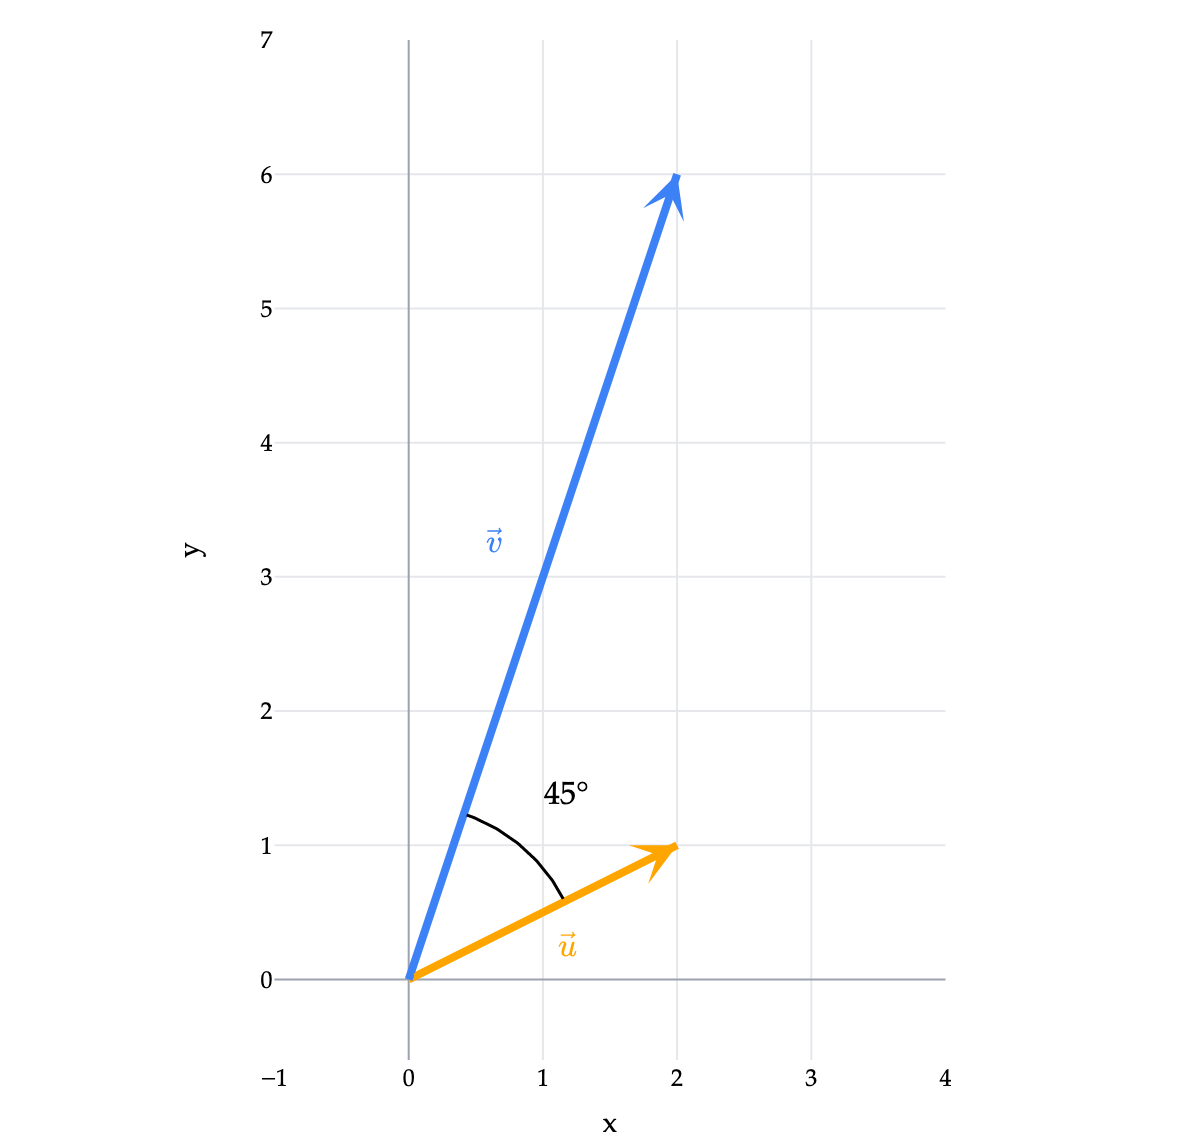

In [2]:
vectors = [((2,1),'orange',r'$\vec u$'),((2,6),'#3d81f6',r'$\vec v$')]
fig = plot_vectors(vectors)
fig.layout.annotations[1].update(x=1.2,y=0.3)
fig.layout.annotations[3].update(x=0.65,y=3.3)
fig.update_layout(width=600,height=570,xaxis_title='x',yaxis_title='y',margin=dict(l=40,r=30,t=20,b=40))
fig.update_xaxes(range=[-1,4],dtick=1,constrain='domain')
fig.update_yaxes(range=[-0.6,7],dtick=1,scaleanchor='x',scaleratio=1)
finish_vectors(fig,vectors)
arc = np.linspace(np.arctan2(1,2),np.arctan2(6,2),60)
fig.add_trace(go.Scatter(x=1.3*np.cos(arc),y=1.3*np.sin(arc),mode='lines',
    line=dict(color='black',width=1.5),showlegend=False))
mid = arc.mean()
fig.add_annotation(x=1.8*np.cos(mid),y=1.8*np.sin(mid),text='45°',showarrow=False,font=dict(color='black',size=16))
fig.show(scale=2)

### Example in ℝ³

Now, let

$${\color{#3d81f6} \vec w}={\color{#3d81f6} \begin{bmatrix}5\\0\\-4\end{bmatrix}},\qquad
{\color{orange} \vec x}={\color{orange} \begin{bmatrix}9\\1\\2\end{bmatrix}}.$$

We have

$${\color{#3d81f6}\vec w}\cdot{\color{orange}\vec x}={\color{#3d81f6} 5}({\color{orange} 9})+{\color{#3d81f6} 0}({\color{orange} 1})+({\color{#3d81f6} -4})({\color{orange} 2})=37,$$

and

$$\begin{aligned}
\lVert{\color{#3d81f6} \vec w}\rVert&=\sqrt{{\color{#3d81f6} 5}^2+{\color{#3d81f6} 0}^2+({\color{#3d81f6} -4})^2}={\color{#3d81f6} \sqrt{41}},\\
\lVert{\color{orange} \vec x}\rVert&=\sqrt{{\color{orange} 9}^2+{\color{orange} 1}^2+{\color{orange} 2}^2}={\color{orange} \sqrt{86}}.
\end{aligned}$$

So their cosine similarity is

$$\cos\theta=\frac{37}{{\color{#3d81f6} \sqrt{41}}{\color{orange} \sqrt{86}}}.$$

This is an exact answer. If we wanted the angle in degrees, we could use a calculator in degree mode:

$$\theta=\cos^{-1}\left(\frac{37}{{\color{#3d81f6} \sqrt{41}}{\color{orange} \sqrt{86}}}\right)\approx51.5^\circ.$$

Draw both vectors from the origin. The shading below shows part of the plane containing them, and the black arc marks their angle. **Drag the figure to rotate it.** The angle may look different from different viewpoints, but its value stays the same.


In [3]:
w = np.array([5.0, 0.0, -4.0])
x = np.array([9.0, 1.0, 2.0])
vectors = [(tuple(w), '#3d81f6', '<b>w</b>'), (tuple(x), 'orange', '<b>x</b>')]
fig = plot_vectors(vectors)
finish_vectors(fig, vectors, renderer='plotly_mimetype')

# The circular arc lies in the plane of the two vectors.
e1 = w / np.linalg.norm(w)
x_unit = x / np.linalg.norm(x)
theta = np.arccos(np.clip(np.dot(e1, x_unit), -1, 1))
e2 = x_unit - np.dot(e1, x_unit) * e1
e2 /= np.linalg.norm(e2)
angles = np.linspace(0, theta, 80)
arc = 2.1 * (np.cos(angles)[:, None] * e1 + np.sin(angles)[:, None] * e2)

plane = np.array([-0.07 * (w + x), 1.08 * w, 1.08 * x])
fig.add_trace(go.Mesh3d(
    x=plane[:, 0], y=plane[:, 1], z=plane[:, 2],
    i=[0], j=[1], k=[2], color='#9ca3af', opacity=0.16,
    flatshading=True, hoverinfo='skip', showlegend=False,
))
fig.add_trace(go.Scatter3d(
    x=arc[:, 0], y=arc[:, 1], z=arc[:, 2], mode='lines',
    line=dict(color='black', width=5), hoverinfo='skip', showlegend=False,
))
label = 3.7 * (np.cos(theta / 2) * e1 + np.sin(theta / 2) * e2)
fig.add_trace(go.Scatter3d(
    x=[label[0]], y=[label[1]], z=[label[2]], mode='text',
    text=[f'θ ≈ {np.degrees(theta):.1f}°'],
    textfont=dict(family='Palatino', color='black', size=17),
    hoverinfo='skip', showlegend=False,
))
fig.data[2].update(x=[2.2], y=[0], z=[-3.2], text=['<b>w</b>'], textfont=dict(color='#3d81f6', size=20))
fig.data[5].update(x=[5.3], y=[0.6], z=[1.9], text=['<b>x</b>'], textfont=dict(color='orange', size=20))
fig.update_layout(
    width=590, height=520, margin=dict(l=0, r=0, t=20, b=0),
    scene=dict(
        xaxis=dict(title='x', range=[-1.5, 11], dtick=2),
        yaxis=dict(title='y', range=[-1.5, 2.5], dtick=1),
        zaxis=dict(title='z', range=[-6, 4.5], dtick=2),
        aspectmode='data', camera=dict(eye=dict(x=1.2, y=-2.2, z=0.8)),
    ),
)
fig.show(config={'displaylogo': False, 'scrollZoom': False})


::::{tip} Activity 2
Let $\vec a=\begin{bmatrix}1\\2\\2\end{bmatrix}$ and $\vec b=\begin{bmatrix}2\\1\\-2\end{bmatrix}$.

1. Find the cosine of the angle between $\vec a$ and $\vec b$. What is the angle?
2. Find the cosine of the angle between $\vec a$ and $\vec a+\vec b$.
3. Find the cosine of the angle between $\vec a$ and $-\vec a$. What is the angle?

:::{tip} Solution
:class: dropdown

1. $\vec a\cdot\vec b=2+2-4=0$ and both norms are 3, so $\cos\theta=0$ and $\theta=90^\circ$.
2. $\vec a+\vec b=\begin{bmatrix}3\\3\\0\end{bmatrix}$, with norm $\sqrt{18}$. Since $\vec a\cdot(\vec a+\vec b)=3+6+0=9$, the cosine is $\frac{9}{3\sqrt{18}}=\frac{1}{\sqrt{2}}$.
3. $\vec a\cdot(-\vec a)=-9$, so the cosine is $\frac{-9}{3(3)}=-1$ and the angle is $180^\circ$.
:::
::::


### Interpreting the sign

Since both lengths are positive, the dot product and cosine similarity have the **same sign**. We can interpret that sign geometrically:

| Dot product | Angle between nonzero vectors |
| --- | --- |
| Positive | $0^\circ\leq\theta<90^\circ$: the directions are less than a right angle apart. |
| Zero | $\theta=90^\circ$: the vectors are perpendicular. |
| Negative | $90^\circ<\theta\leq180^\circ$: the directions are more than a right angle apart. |

A cosine similarity of $1$ means the vectors point in the same direction; $-1$ means they point in opposite directions. The closer it is to 1, the smaller the angle between them.

Let's keep ${\color{orange} \vec u}={\color{orange} \begin{bmatrix}2\\1\end{bmatrix}}$ fixed and compare it with four different vectors.


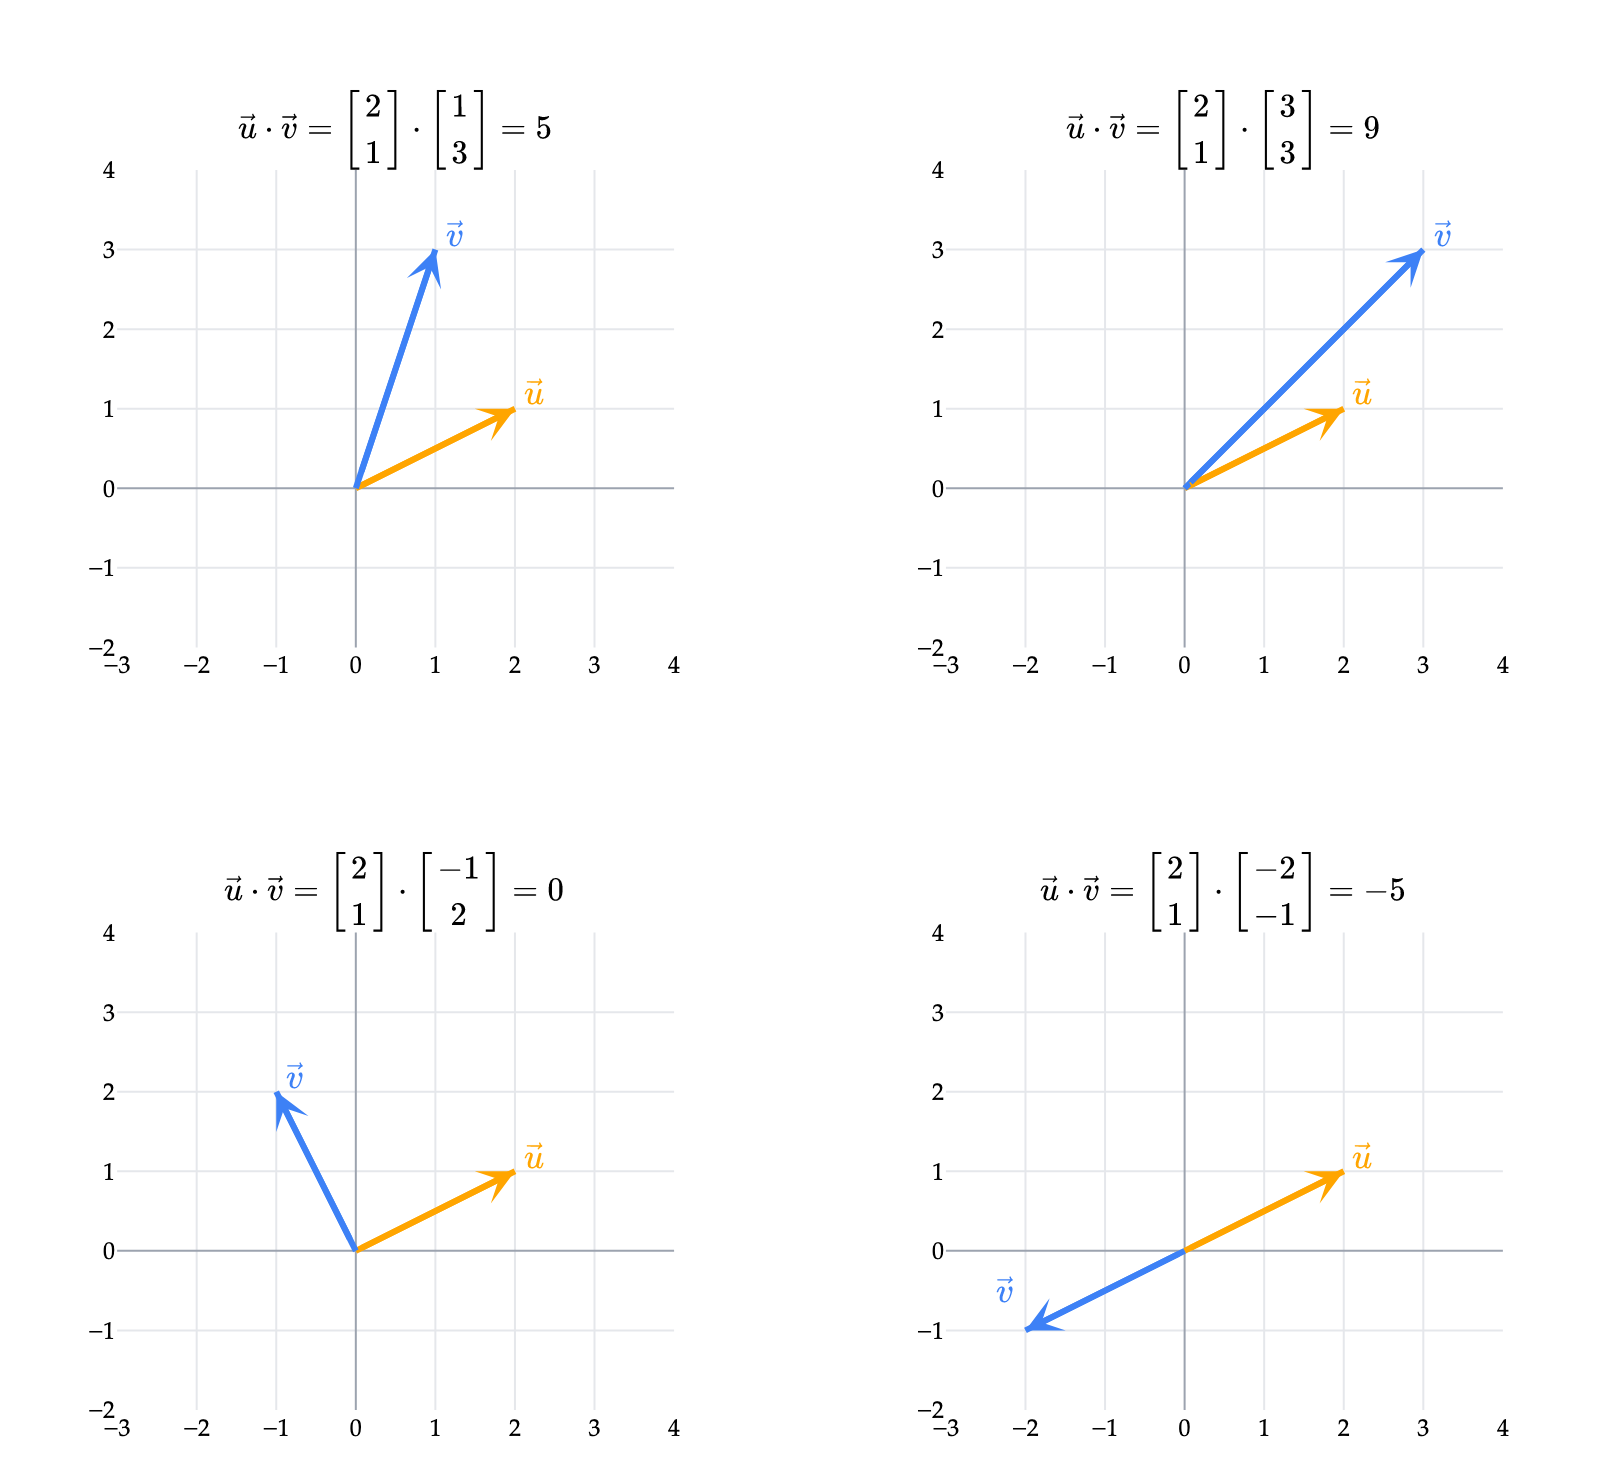

In [4]:
from plotly.subplots import make_subplots

test_vectors = [(1,3), (3,3), (-1,2), (-2,-1)]
titles = [
    rf'$\vec u\cdot\vec v = \begin{{bmatrix}}2\\1\end{{bmatrix}}\cdot\begin{{bmatrix}}{a}\\{b}\end{{bmatrix}} = {2*a+b}$'
    for a, b in test_vectors
]
fig = make_subplots(rows=2, cols=2, subplot_titles=titles, horizontal_spacing=0.12, vertical_spacing=0.23)
_style_plotly(fig, renderer='png')
for i, endpoint in enumerate(test_vectors):
    row, col = divmod(i, 2)
    row, col = row+1, col+1
    axis_num = i+1
    xref = 'x' if axis_num == 1 else f'x{axis_num}'
    yref = 'y' if axis_num == 1 else f'y{axis_num}'
    for point, color, label in [((2,1),'orange',r'$\vec u$'),(endpoint,'#3d81f6',r'$\vec v$')]:
        fig.add_trace(go.Scatter(x=[0,point[0]],y=[0,point[1]],mode='lines',
            line=dict(color=color,width=3),showlegend=False),row=row,col=col)
        fig.add_annotation(x=point[0],y=point[1],ax=0,ay=0,xref=xref,yref=yref,
            axref=xref,ayref=yref,showarrow=True,arrowhead=3,arrowwidth=3,arrowcolor=color)
        fig.add_annotation(x=point[0]+0.25,y=point[1]+0.25,xref=xref,yref=yref,
            text=label,showarrow=False,font=dict(color=color,size=17))
    if i == 3:
        fig.layout.annotations[-1].update(x=-2.25, y=-0.45)
    fig.update_xaxes(range=[-3,4],dtick=1,constrain='domain',row=row,col=col)
    fig.update_yaxes(range=[-2,4],dtick=1,scaleanchor=xref,scaleratio=1,row=row,col=col)
fig.update_layout(width=800,height=740,margin=dict(l=35,r=25,t=85,b=35))
fig.show(scale=2)

The first two dot products are positive, the third is zero, and the fourth is negative. In the fourth picture, the vectors point in exactly opposite directions, so the angle is $180^\circ$ and their cosine similarity is $-1$.

### Why divide by the lengths?

Be careful when comparing the **sizes** of dot products: they depend on the lengths as well as the angle. Doubling one vector doubles the dot product without changing its direction. **Cosine similarity removes this dependence on length**: its numerator and denominator both double, so the ratio stays the same. More generally, multiplying either vector by a positive scalar leaves their cosine similarity unchanged.

This connects directly to **unit vectors**, which describe direction. The cosine similarity is the dot product of the two vectors after normalizing them:

$$\frac{{\color{orange} \vec u}}{\lVert{\color{orange} \vec u}\rVert}\cdot\frac{{\color{#3d81f6} \vec v}}{\lVert{\color{#3d81f6} \vec v}\rVert}
=\frac{{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}}{\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert}.$$


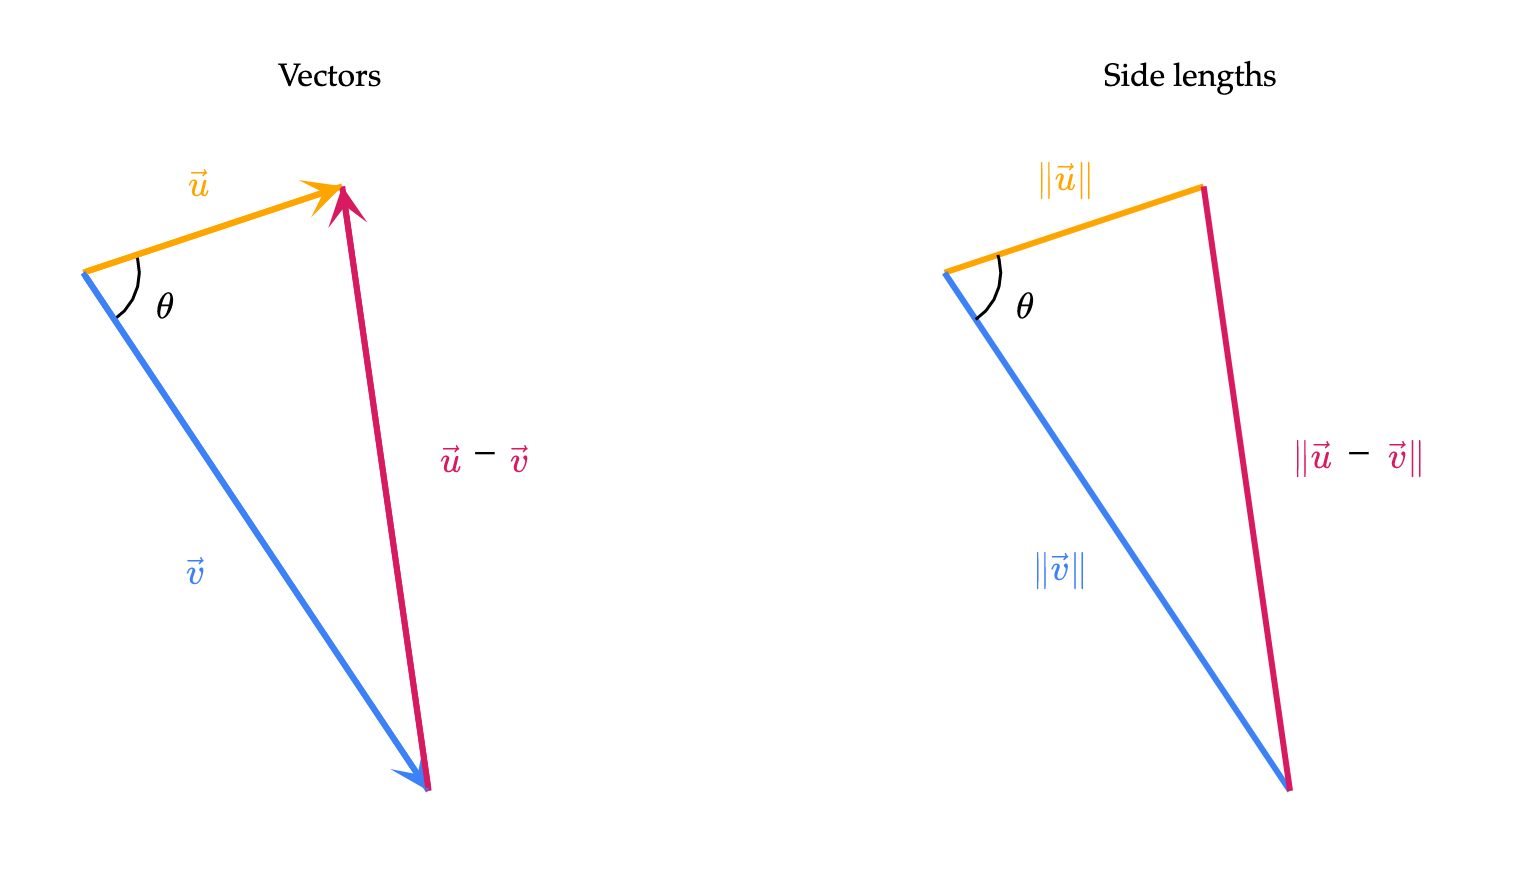

In [5]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

proof_u = np.array([3., 1.])
proof_v = np.array([4., -6.])
proof_colors = ['orange', '#3d81f6', '#d81a60']
proof_fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.18,
                         subplot_titles=['Vectors', 'Side lengths'])
proof_sides = [(np.zeros(2), proof_u), (np.zeros(2), proof_v), (proof_v, proof_u)]
proof_labels = [
    [r'$\vec u$', r'$\vec v$', r'$\vec u - \vec v$'],
    [r'$\lVert\vec u\rVert$', r'$\lVert\vec v\rVert$', r'$\lVert\vec u - \vec v\rVert$']
]
proof_label_positions = [(1.35, 1.1), (1.3, -3.4), (4.55, -2.1)]
for panel in [1, 2]:
    xref = 'x' if panel == 1 else 'x2'
    yref = 'y' if panel == 1 else 'y2'
    for i, ((start, end), color) in enumerate(zip(proof_sides, proof_colors)):
        proof_fig.add_trace(go.Scatter(
            x=[start[0], end[0]], y=[start[1], end[1]], mode='lines',
            line=dict(color=color, width=3), showlegend=False, hoverinfo='skip'), row=1, col=panel)
        if panel == 1:
            proof_fig.add_annotation(x=end[0], y=end[1], ax=start[0], ay=start[1],
                xref=xref, yref=yref, axref=xref, ayref=yref, text='',
                showarrow=True, arrowhead=3, arrowsize=1.1, arrowwidth=3, arrowcolor=color)
        x, y = proof_label_positions[i]
        if i == 2:
            # Separate annotations keep the subtraction sign black in PNG exports.
            pieces = [(4.25, r'$\vec u$', color), (4.65, '−', 'black'), (5.05, r'$\vec v$', color)]
            if panel == 2:
                pieces = [(4.25, r'$\lVert\vec u$', color), (4.8, '−', 'black'), (5.35, r'$\vec v\rVert$', color)]
            for label_x, label_text, label_color in pieces:
                proof_fig.add_annotation(x=label_x, y=y, xref=xref, yref=yref,
                    text=label_text, showarrow=False, font=dict(color=label_color, size=18))
        else:
            proof_fig.add_annotation(x=x, y=y, xref=xref, yref=yref,
                text=proof_labels[panel-1][i], showarrow=False, font=dict(color=color, size=18))
    angles=np.linspace(np.arctan2(proof_v[1], proof_v[0]), np.arctan2(proof_u[1], proof_u[0]), 80)
    proof_fig.add_trace(go.Scatter(x=0.65*np.cos(angles), y=0.65*np.sin(angles),
        mode='lines', line=dict(color='black',width=1.5), showlegend=False, hoverinfo='skip'),row=1,col=panel)
    proof_fig.add_annotation(x=0.95,y=-0.35,xref=xref,yref=yref,text=r'$\theta$',
        showarrow=False,font=dict(color='black',size=19))
    proof_fig.update_xaxes(range=[-0.6,6.3],visible=False,constrain='domain',row=1,col=panel)
    proof_fig.update_yaxes(range=[-6.8,2.0],visible=False,scaleanchor=xref,scaleratio=1,row=1,col=panel)
proof_fig.update_layout(width=760,height=440,margin=dict(l=15,r=15,t=50,b=10),
    paper_bgcolor='white',plot_bgcolor='white',font=dict(family='Palatino',size=18,color='black'))
Path('imgs').mkdir(exist_ok=True)
proof_fig.write_image('imgs/dot-product-proof.png',scale=2)
proof_fig.show(renderer='png',scale=2)


:::{attention} What you need to know
You are responsible for using both formulas for the dot product and understanding what they tell us. **You are not responsible for the proof that the two formulas are equivalent.** The optional proof is in the dropdown below.
:::

:::{note} Optional proof: Why the two formulas agree
:class: dropdown

Let's consider two nonzero vectors, ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$, in $\mathbb{R}^2$ or $\mathbb{R}^3$. Draw them from the same starting point. In three dimensions, two vectors that do not point along the same line lie in a plane, so we can still use ordinary triangle geometry.

Along with them, let's consider their **difference**, ${\color{#d81a60} \vec u}-{\color{#d81a60} \vec v}$. This step may seem arbitrary, but we'll see why it's useful soon. The diagram shows the same triangle twice: first with its vectors, then with its side lengths. We haven't put numbers on the vectors, since the proof should work in general.

```{figure} imgs/dot-product-proof.png
:width: 700px
:alt: Two views of the same triangle. An orange vector u points up and right, a blue vector v points down and right, and a magenta difference vector runs from the tip of v to the tip of u. The angle theta is at their common starting point. The second view labels the three side lengths.
```

Which way should the difference arrow point? Start by walking along ${\color{#3d81f6} \vec v}$, then walk along ${\color{#d81a60} \vec u}-{\color{#d81a60} \vec v}$. You end up at the tip of ${\color{orange} \vec u}$, just as we'd expect from

$${\color{#3d81f6} \vec v}+({\color{orange} \vec u}-{\color{#3d81f6} \vec v})={\color{orange} \vec u}.$$

So the magenta arrow points **from the tip of ${\color{#3d81f6} \vec v}$ to the tip of ${\color{orange} \vec u}$**. Its length, $\lVert{\color{#d81a60} \vec u}-{\color{#d81a60} \vec v}\rVert$, is the distance between the two tips, as we learned in [Chapter 1.5](01-05.ipynb). We'll find two expressions for the square of this distance.

**First, use the law of cosines.** A triangle with sides of lengths $a$ and $b$ enclosing an angle $\theta$ has opposite side length $c$ satisfying

$$c^2=a^2+b^2-2ab\cos\theta.$$

In our triangle, $a={\color{orange} \lVert\vec u\rVert}$, $b={\color{#3d81f6} \lVert\vec v\rVert}$, and $c=\lVert{\color{#d81a60} \vec u}-{\color{#d81a60} \vec v}\rVert$. Therefore,

$$\lVert{\color{#d81a60} \vec u}-{\color{#d81a60} \vec v}\rVert^2={\color{orange} \lVert\vec u\rVert}^2+{\color{#3d81f6} \lVert\vec v\rVert}^2-2{\color{orange} \lVert\vec u\rVert}{\color{#3d81f6} \lVert\vec v\rVert}\cos\theta.$$

**Second, use the computational formula.** Taking the dot product of a vector with itself gives its squared length, so

$$\begin{aligned}
\lVert{\color{#d81a60} \vec u}-{\color{#d81a60} \vec v}\rVert^2
&=({\color{orange} \vec u}-{\color{#3d81f6} \vec v})\cdot({\color{orange} \vec u}-{\color{#3d81f6} \vec v})\\
&={\color{orange} \vec u}\cdot{\color{orange} \vec u}-{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}\\
&\qquad-{\color{#3d81f6} \vec v}\cdot{\color{orange} \vec u}+{\color{#3d81f6} \vec v}\cdot{\color{#3d81f6} \vec v}\\
&={\color{orange} \lVert\vec u\rVert}^2-2{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}+{\color{#3d81f6} \lVert\vec v\rVert}^2.
\end{aligned}$$

In the last step, we combined the two middle terms because ${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}={\color{#3d81f6} \vec v}\cdot{\color{orange} \vec u}$.

Let's take a step back. We've found **two expressions for the same squared distance**, so they must be equal:

$$\begin{aligned}
&{\color{orange} \lVert\vec u\rVert}^2+{\color{#3d81f6} \lVert\vec v\rVert}^2-2{\color{orange} \lVert\vec u\rVert}{\color{#3d81f6} \lVert\vec v\rVert}\cos\theta\\
&\qquad={\color{orange} \lVert\vec u\rVert}^2+{\color{#3d81f6} \lVert\vec v\rVert}^2-2{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}.
\end{aligned}$$

Subtracting the two squared-length terms from both sides gives

$$-2{\color{orange} \lVert\vec u\rVert}{\color{#3d81f6} \lVert\vec v\rVert}\cos\theta=-2{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}.$$

Finally, divide both sides by $-2$:

$${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}={\color{orange} \lVert\vec u\rVert}{\color{#3d81f6} \lVert\vec v\rVert}\cos\theta.$$

This proves that the two formulas agree! If the vectors point along the same line, the triangle is flat. The same law-of-cosines identity still holds with $\theta=0^\circ$ or $180^\circ$.
:::


---

## Orthogonality

**Orthogonal** is the word we use for perpendicular vectors. The geometric formula gives us an especially useful test: for nonzero vectors, the angle is $90^\circ$ exactly when the dot product is zero, because $\cos 90^\circ=0$.

:::{note} Definition: Orthogonal vectors
Two vectors ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ are **orthogonal** if

$${\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}=0.$$

We write ${\color{orange} \vec u}\perp{\color{#3d81f6} \vec v}$. For nonzero vectors, this means that the angle between them is $90^\circ$.
:::

This definition applies to any two vectors with the same number of components, no matter how many components they have. For example, two vectors $\vec u,\vec v\in\mathbb{R}^{15}$ are orthogonal exactly when $\vec u\cdot\vec v=0$. We don't need to picture 15-dimensional space to check this: orthogonal means their dot product is zero.

For example,

$${\color{orange} \begin{bmatrix}2\\1\end{bmatrix}}\cdot{\color{#3d81f6} \begin{bmatrix}-1\\2\end{bmatrix}}
={\color{orange} 2}({\color{#3d81f6} -1})+{\color{orange} 1}({\color{#3d81f6} 2})=0,$$

so these vectors are orthogonal. The picture below shows these two perpendicular vectors.



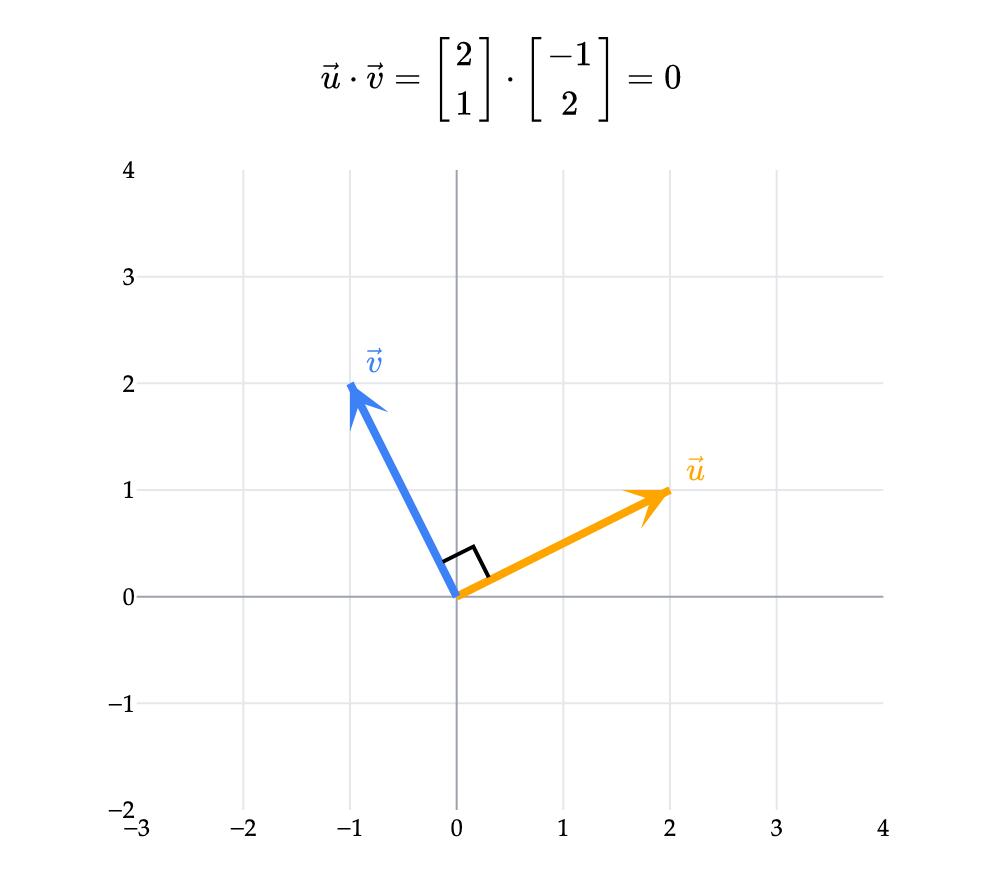

In [6]:
vectors = [((2,1), 'orange', r'$\vec u$'), ((-1,2), '#3d81f6', r'$\vec v$')]
fig = plot_vectors(vectors)
finish_vectors(fig, vectors)
fig.layout.annotations[1].update(x=2.25, y=1.25)
fig.layout.annotations[3].update(x=-0.75, y=2.25)
fig.update_xaxes(range=[-3,4], dtick=1, constrain='domain')
fig.update_yaxes(range=[-2,4], dtick=1, scaleanchor='x', scaleratio=1)
fig.update_layout(
    width=500, height=440, margin=dict(l=35,r=25,t=85,b=35),
    title=dict(text=r'$\vec u\cdot\vec v = \begin{bmatrix}2\\1\end{bmatrix}\cdot\begin{bmatrix}-1\\2\end{bmatrix} = 0$', x=0.5),
)
# The two sides of the marker follow the perpendicular unit directions.
u_direction = np.array([2., 1.]) / np.sqrt(5)
v_direction = np.array([-1., 2.]) / np.sqrt(5)
corner = 0.35 * np.array([u_direction, u_direction + v_direction, v_direction])
fig.add_trace(go.Scatter(
    x=corner[:, 0], y=corner[:, 1], mode='lines',
    line=dict(color='black', width=2), showlegend=False, hoverinfo='skip',
))
fig.show(renderer='png', scale=2)


The definition also makes $\vec 0$ orthogonal to **every** vector, since $\vec 0\cdot{\color{#3d81f6} \vec v}=0$.

::::{tip} Activity 3
Let $\vec u=\begin{bmatrix}2\\-1\\3\end{bmatrix}$ and $\vec v=\begin{bmatrix}1\\t\\2\end{bmatrix}$.

1. Find $t$ so that $\vec u$ and $\vec v$ are orthogonal.
2. For that value of $t$, are $2\vec u$ and $-3\vec v$ also orthogonal? Explain using a dot product property.

:::{tip} Solution
:class: dropdown

1. $\vec u\cdot\vec v=2-t+6=8-t$. Setting this equal to 0 gives $t=8$.
2. Yes: $(2\vec u)\cdot(-3\vec v)=-6(\vec u\cdot\vec v)=-6(0)=0$.
:::
::::

### Orthogonality and the Pythagorean theorem

In [Chapter 1.5](01-05.ipynb), we used the Pythagorean theorem to define the length of a vector. Here, we've already learned that the dot product operation and the length of a vector are closely related: for any vector $\vec x$,

$$\vec x\cdot\vec x=\lVert\vec x\rVert^2.$$

What happens if we apply this equality to the sum of two vectors, ${\color{orange} \vec u} + {\color{#3d81f6} \vec v}$? Using the distributive property of the dot product,

$$\begin{aligned}
\lVert{\color{orange} \vec u}+{\color{#3d81f6} \vec v}\rVert^2
&=({\color{orange} \vec u}+{\color{#3d81f6} \vec v})\cdot({\color{orange} \vec u}+{\color{#3d81f6} \vec v})\\
&={\color{orange} \vec u}\cdot{\color{orange} \vec u}+{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}+{\color{#3d81f6} \vec v}\cdot{\color{orange} \vec u}+{\color{#3d81f6} \vec v}\cdot{\color{#3d81f6} \vec v}\\
&=\lVert{\color{orange} \vec u}\rVert^2+2{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}+\lVert{\color{#3d81f6} \vec v}\rVert^2.
\end{aligned}$$

If ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$ are orthogonal, the middle term is zero, leaving

$$\lVert{\color{orange} \vec u}+{\color{#3d81f6} \vec v}\rVert^2=\lVert{\color{orange} \vec u}\rVert^2+\lVert{\color{#3d81f6} \vec v}\rVert^2.$$

This is the Pythagorean theorem! For nonzero vectors in two or three dimensions, draw them tip-to-tail: they form the perpendicular legs of a right triangle, and their sum is the hypotenuse. The algebra also works in higher dimensions. It tells us exactly when we can add the squared lengths: **when the two vectors are orthogonal**.


---

(cauchy-schwarz-inequality)=
## The Cauchy–Schwarz inequality

How large can a dot product be? The answer depends on the lengths of the two vectors.

:::{note} Cauchy–Schwarz inequality
For any vectors ${\color{orange} \vec u},{\color{#3d81f6} \vec v}\in\mathbb{R}^n$,

$$|{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}|\leq\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert.$$

We'll accept this inequality without proof. It can be proved directly from the components, without first defining an angle. [Here's a video](https://www.khanacademy.org/math/linear-algebra/vectors-and-spaces/dot-cross-products/v/proof-of-the-cauchy-schwarz-inequality) with a proof that doesn't involve geometry.
:::

This says that the absolute value of the dot product is at most the product of the vectors' lengths. For two nonzero vectors, both lengths are positive, so we can divide by their product to get

$$\left|\frac{{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}}{\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert}\right|\leq1.$$

The quantity inside the absolute value is the cosine similarity of ${\color{orange} \vec u}$ and ${\color{#3d81f6} \vec v}$. So the cosine similarity has absolute value at most $1$. Remember that $|x|\leq1$ means $-1\leq x\leq1$. This is reassuring: the cosine similarity is the cosine of the angle between the vectors, and the cosine function only takes values between $-1$ and $1$, inclusive.

We can also rewrite the original inequality without absolute values:

$$-\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert\leq{\color{orange} \vec u}\cdot{\color{#3d81f6} \vec v}\leq\lVert{\color{orange} \vec u}\rVert\lVert{\color{#3d81f6} \vec v}\rVert.$$

For nonzero vectors, we can interpret these bounds using the geometric formula. The upper bound occurs when the vectors point in the same direction, and the lower bound occurs when they point in opposite directions. If either vector is zero, the dot product and both bounds are zero.

For example, if $\lVert{\color{orange} \vec u}\rVert={\color{orange} 5}$ and $\lVert{\color{#3d81f6} \vec v}\rVert={\color{#3d81f6} 12}$, their dot product must be between $-60$ and $60$. It is 60 when they point in the same direction, and $-60$ when they point in opposite directions.

Homework 2 will have questions that develop this idea further.

---

## Application: Work done by a force

Suppose you pull an object along a straight track. A force pointing in the direction of the displacement does positive work; a perpendicular force does no work.

For a **constant force** $\vec F$ acting while an object undergoes displacement $\vec d$, the **work** done by that force is

$$W=\vec F\cdot\vec d.$$

If both vectors are nonzero, the geometric formula gives the familiar formula from physics,

$$W=\lVert\vec F\rVert\lVert\vec d\rVert\cos\theta,$$

where $\theta$ is the angle between the force and displacement. If either vector is zero, the dot product tells us directly that the work is zero.

If force is measured in newtons and displacement in meters, work is measured in **joules**.

For example, suppose $\vec F=\begin{bmatrix}3\\4\end{bmatrix}$ newtons and the object moves $\vec d=\begin{bmatrix}2\\0\end{bmatrix}$ meters along a horizontal track. Then

$$W=3(2)+4(0)=6\text{ joules}.$$

The vertical component of this force contributes no work because there is no vertical displacement.

::::{tip} Activity 4
An object moves through displacement $\vec d=\begin{bmatrix}3\\4\end{bmatrix}$ meters. Compute the work done by each constant force, considered separately:

1. $\vec F_1=\begin{bmatrix}6\\8\end{bmatrix}$ newtons.
2. $\vec F_2=\begin{bmatrix}-4\\3\end{bmatrix}$ newtons.
3. $\vec F_3=\begin{bmatrix}-3\\-4\end{bmatrix}$ newtons.

For each one, explain how the sign of the work relates to the force's direction relative to the displacement.

:::{tip} Solution
:class: dropdown

1. $W_1=6(3)+8(4)=50$ joules. The force points in the same direction as the displacement, so it does positive work.
2. $W_2=-4(3)+3(4)=0$ joules. The force is perpendicular to the displacement.
3. $W_3=-3(3)-4(4)=-25$ joules. The force points opposite to the displacement, so it does negative work.
:::
::::
